# American Put Dataset Analysis and Validation

## Production Design, Exercise-Boundary Coverage, and Frozen Data Splits

**SoftUni Deep Learning Final Project**  
**Author:** Kamen Dimitrov  
**Notebook:** `03_dataset_analysis_and_validation.ipynb`

---

This notebook audits the pilot dataset created in Notebook 02 and freezes the experimental data design before neural-network training begins. Its role is not to optimize a model. It establishes whether the labels, parameter coverage, exercise decisions, and split strategy are credible enough to support the later experiments.

The notebook follows five controls:

1. no missing, infinite, duplicated, or structurally invalid observations;
2. explicit reporting of finite-tree pricing-floor adjustments;
3. separate analysis of the early-exercise premium and exercise decision;
4. deterministic and reusable train/validation/test assignments;
5. out-of-domain regimes defined before model performance is observed.

# 1. Environment and configuration

The executable source of truth remains under `src/`. The notebook calls reusable validation and splitting functions, then explains their outputs. The pilot dataset is expected at `data/generated/american_put_pilot.csv`, as produced by Notebook 02. If it is absent, the notebook creates a small replacement pilot so the analysis remains reproducible.

In [1]:
from pathlib import Path
import json
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

NOTEBOOK_DIR = Path.cwd().resolve()
PROJECT_ROOT = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == "notebooks" else NOTEBOOK_DIR
DATA_DIR = PROJECT_ROOT / "data" / "generated"
MANIFEST_DIR = PROJECT_ROOT / "data" / "manifests"

for directory in (DATA_DIR, MANIFEST_DIR):
    directory.mkdir(parents=True, exist_ok=True)

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

PILOT_PATH = DATA_DIR / "american_put_pilot.csv"
PILOT_SPLIT_PATH = MANIFEST_DIR / "pilot_split_assignments.csv"
PILOT_SPLIT_MANIFEST_PATH = MANIFEST_DIR / "pilot_split_manifest.json"
DATASET_DESIGN_PATH = MANIFEST_DIR / "dataset_design.json"

RANDOM_SEED = 42
FALLBACK_PILOT_SIZE = 2_000
FALLBACK_TREE_STEPS = 250

print(f"Project root: {PROJECT_ROOT}")
print(f"Pilot path:   {PILOT_PATH}")

Project root: D:\Users\kamen.dimitrov\Desktop\SOFTUNI\AI_and_ML_upskill_program\Deep_Learning\deep_learning_american_option_pricing
Pilot path:   D:\Users\kamen.dimitrov\Desktop\SOFTUNI\AI_and_ML_upskill_program\Deep_Learning\deep_learning_american_option_pricing\data\generated\american_put_pilot.csv


In [2]:
from src.data.dataset_validation import (
    assert_dataset_quality,
    build_dataset_quality_report,
    load_option_dataset,
)
from src.data.generation import (
    ParameterRanges,
    generate_american_put_dataset,
    save_generated_dataset,
)
from src.data.splitting import (
    DEFAULT_OOD_SPECS,
    SplitConfig,
    build_split_manifest,
    create_train_validation_test_split,
    save_split_assignments,
    save_split_manifest,
    validate_split_integrity,
)

# 2. Load or reconstruct the pilot dataset

The fallback branch is operational rather than methodological. Notebook 02 remains the preferred source because it records the selected tree resolution and runtime analysis. The fallback allows a grader to execute Notebook 03 independently, but its tree resolution should not silently replace the production decision made in Notebook 02.

In [3]:
if PILOT_PATH.exists():
    pilot = load_option_dataset(PILOT_PATH)
    pilot_source = "Loaded from Notebook 02 output"
else:
    pilot = generate_american_put_dataset(
        n_samples=FALLBACK_PILOT_SIZE,
        tree_steps=FALLBACK_TREE_STEPS,
        seed=RANDOM_SEED,
        strike=100.0,
    )
    save_generated_dataset(pilot, PILOT_PATH)
    pilot_source = "Generated by Notebook 03 fallback"

print(pilot_source)
print(f"Pilot observations: {len(pilot):,}")
pilot.head()

Loaded from Notebook 02 output
Pilot observations: 2,000


,sample_id,spot,strike,moneyness,log_moneyness,time_to_maturity,risk_free_rate,dividend_yield,volatility,intrinsic_value,...,european_price,raw_american_price,american_price,pricing_floor_adjustment,early_exercise_premium,normalized_european_price,normalized_american_price,normalized_early_exercise_premium,exercise_now,tree_steps
0,0,78.688431,100.0,0.786884,-0.239674,1.140733,0.056637,0.019900,0.485814,21.311569,...,27.099258,28.259164,28.259164,0.0,1.159906,0.270993,0.282592,0.011599,False,250
1,1,105.696645,100.0,1.056966,0.055403,0.877895,0.031979,0.001129,0.297437,0.000000,...,7.543624,7.732337,7.732337,0.0,0.188713,0.075436,0.077323,0.001887,False,250
2,2,73.656705,100.0,0.736567,-0.305755,1.181202,0.046943,0.018109,0.592465,26.343295,...,34.071323,35.088643,35.088643,0.0,1.017320,0.340713,0.350886,0.010173,False,250
3,3,129.414815,100.0,1.294148,0.257853,0.607714,0.022845,0.004246,0.722531,0.000000,...,12.753451,12.820835,12.820835,0.0,0.067384,0.127535,0.128208,0.000674,False,250
4,4,78.142179,100.0,0.781422,-0.246640,0.752982,0.050189,0.048631,0.623639,21.857821,...,30.577114,30.952497,30.952497,0.0,0.375383,0.305771,0.309525,0.003754,False,250


# 3. Structural and financial audit

A deep-learning model can reproduce defects in its labels with high accuracy. Dataset validation is therefore part of the pricing methodology rather than an administrative check.

The audit covers:

- required columns;
- missing and infinite values;
- identifier uniqueness;
- parameter-domain consistency;
- no-arbitrage lower bounds;
- target identities;
- exercise-label consistency;
- frequency and size of finite-tree floor repairs.

In [4]:
quality_report = build_dataset_quality_report(
    pilot,
    ranges=ParameterRanges(),
)

print(f"Overall mandatory checks passed: {quality_report.passed}")
quality_report.schema_checks

Overall mandatory checks passed: True


,check,observed,expected,mandatory,passed
0,Dataset is non-empty,2000,> 0 rows,True,True
1,All required columns are present,[],No missing columns,True,True
2,Required columns contain no missing values,0,0,True,True
3,Numeric columns contain no infinite values,0,0,True,True
4,sample_id is unique,0,0,True,True
5,Parameter vectors are unique,0,0,False,True
6,exercise_now contains only boolean labels,0,0,True,True
7,tree_steps contains positive integers,"{'minimum': 250.0, 'integer_valued': True}",Positive integer values,True,True


In [5]:
quality_report.parameter_checks

,check,observed,expected,mandatory,passed
0,moneyness remains inside generation bounds,"(0.500386978024278, 1.4997600359561307)","(0.5, 1.5)",True,True
1,time_to_maturity remains inside generation bounds,"(0.0194440210510186, 1.999460751842706)","(0.019178082191780823, 2.0)",True,True
2,volatility remains inside generation bounds,"(0.0502186207347044, 0.7996635886153338)","(0.05, 0.8)",True,True
3,risk_free_rate remains inside generation bounds,"(4.53107058400889e-05, 0.0999540550441421)","(0.0, 0.1)",True,True
4,dividend_yield remains inside generation bounds,"(3.3164293867249514e-05, 0.0799803399045812)","(0.0, 0.08)",True,True
5,moneyness equals spot divided by strike,0.0,Maximum absolute difference <= 1e-12,True,True
6,log_moneyness equals log(moneyness),0.0,Maximum absolute difference <= 1e-12,True,True


In [6]:
quality_report.financial_checks

,check,observations,violations,violation_rate,passed
0,American price is non-negative,2000,0,0.0,True
1,American price is not below intrinsic value,2000,0,0.0,True
2,American price is not below European price,2000,0,0.0,True
3,Early-exercise premium is non-negative,2000,0,0.0,True
4,Pricing-floor adjustment is non-negative,2000,0,0.0,True
5,American price equals raw price plus floor adj...,2000,0,0.0,True
6,Premium equals American minus European price,2000,0,0.0,True
7,Normalized American target is consistent,2000,0,0.0,True
8,Normalized European target is consistent,2000,0,0.0,True
9,Normalized premium target is consistent,2000,0,0.0,True


In [7]:
quality_report.floor_summary

,observations,repaired_observations,repair_rate,total_adjustment,mean_adjustment_all,mean_adjustment_when_repaired,median_adjustment_when_repaired,maximum_adjustment
0,2000,276,0.138,0.861446,0.000431,0.003121,0.000737,0.032783


In [8]:
quality_report.exercise_summary

,exercise_now,decision,observations,share
0,False,Continue,1796,0.898
1,True,Exercise,204,0.102


In [9]:
assert_dataset_quality(quality_report)

The pricing-floor adjustment is retained as a separate field because a finite CRR tree may oscillate slightly below the analytical European value. A high repair rate or large adjustment would indicate that the selected tree resolution is unsuitable for production labels even if the repaired dataset satisfies the final no-arbitrage bounds.

# 4. Parameter-domain coverage

Latin hypercube sampling is designed to cover each marginal parameter distribution efficiently. It does not automatically guarantee balanced representation of every economically relevant interaction. The following tables and charts inspect both marginal coverage and selected two-dimensional relationships.

In [10]:
parameter_columns = [
    "moneyness",
    "log_moneyness",
    "time_to_maturity",
    "volatility",
    "risk_free_rate",
    "dividend_yield",
]

pilot[parameter_columns].describe(percentiles=[0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]).T

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
moneyness,2000.0,1.000001,0.288750,0.500387,0.510373,0.550431,0.750215,0.999836,1.249957,1.449566,1.489616,1.499760
log_moneyness,2000.0,-0.045228,0.307957,-0.692374,-0.672613,-0.597054,-0.287395,-0.000164,0.223109,0.371264,0.398518,0.405305
time_to_maturity,2000.0,1.009578,0.571946,0.019444,0.039080,0.118649,0.514555,1.009739,1.504592,1.900337,1.980026,1.999461
volatility,2000.0,0.425002,0.216559,0.050219,0.057619,0.087696,0.237745,0.424840,0.612371,0.762174,0.792399,0.799664
risk_free_rate,2000.0,0.050000,0.028874,0.000045,0.001028,0.005021,0.025006,0.049990,0.074996,0.094974,0.098954,0.099954
dividend_yield,2000.0,0.040001,0.023099,0.000033,0.000818,0.004037,0.020006,0.039994,0.059993,0.075983,0.079188,0.079980


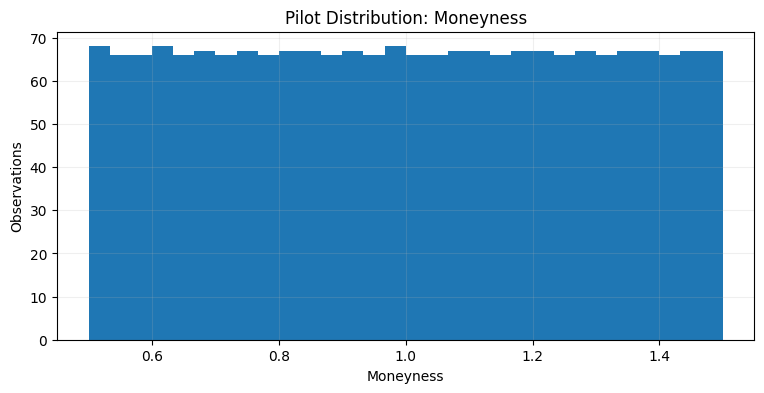

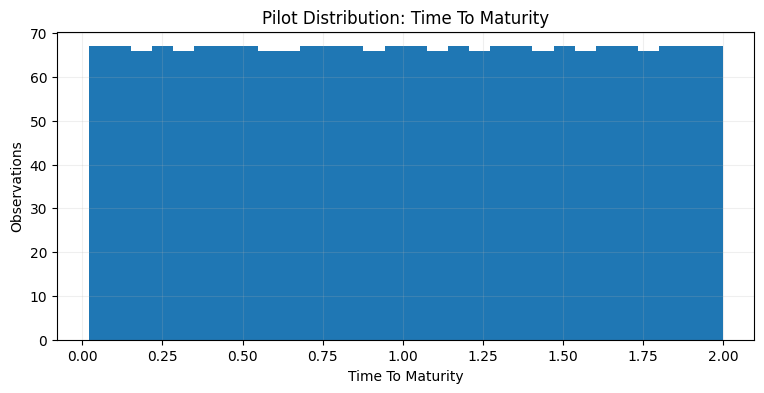

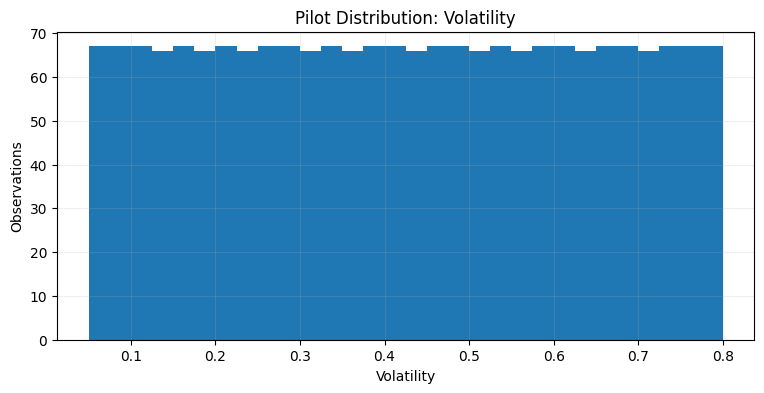

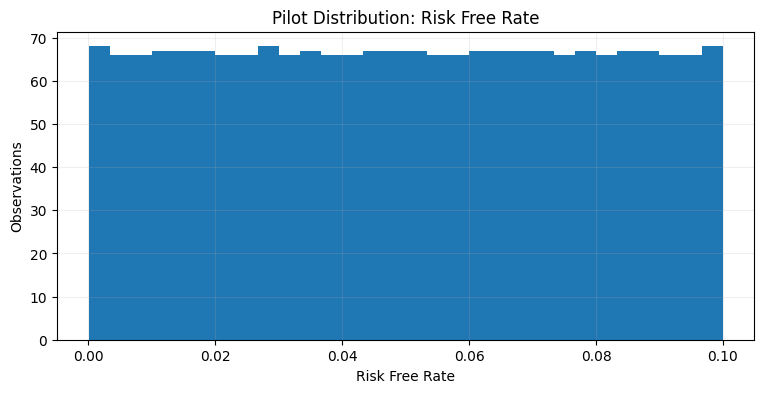

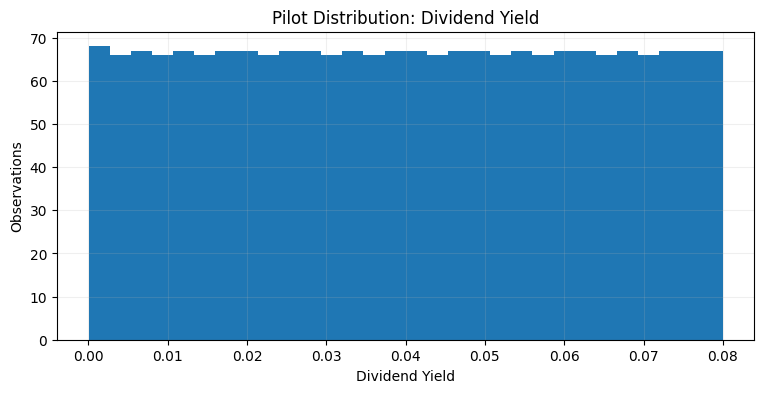

In [11]:
for column in [
    "moneyness",
    "time_to_maturity",
    "volatility",
    "risk_free_rate",
    "dividend_yield",
]:
    plt.figure(figsize=(9, 4))
    plt.hist(pilot[column], bins=30)
    plt.xlabel(column.replace("_", " ").title())
    plt.ylabel("Observations")
    plt.title(f"Pilot Distribution: {column.replace('_', ' ').title()}")
    plt.grid(alpha=0.20)
    plt.show()

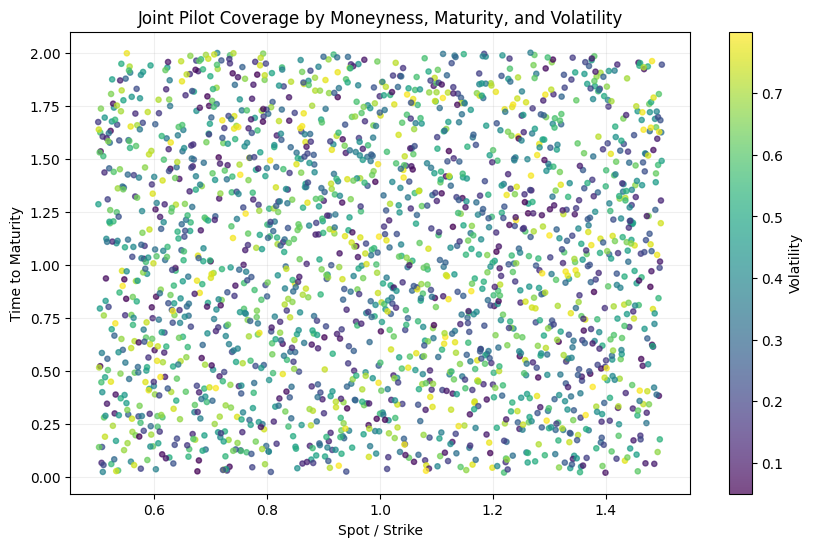

In [12]:
plt.figure(figsize=(10, 6))
scatter = plt.scatter(
    pilot["moneyness"],
    pilot["time_to_maturity"],
    c=pilot["volatility"],
    s=14,
    alpha=0.70,
)
plt.colorbar(scatter, label="Volatility")
plt.xlabel("Spot / Strike")
plt.ylabel("Time to Maturity")
plt.title("Joint Pilot Coverage by Moneyness, Maturity, and Volatility")
plt.grid(alpha=0.20)
plt.show()

# 5. Target distribution and Black–Scholes proxy baseline

For an American put, the error from using the European Black–Scholes value as a direct proxy is exactly the early-exercise premium:

$$
V_A - V_E = EEP.
$$

This creates a mandatory non-neural baseline. A deep-learning model should not be considered useful merely because its absolute error is small; it must materially improve on the European proxy over the same held-out observations.

In [13]:
target_columns = [
    "european_price",
    "american_price",
    "early_exercise_premium",
    "normalized_american_price",
    "normalized_early_exercise_premium",
]

pilot[target_columns].describe(percentiles=[0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]).T

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
european_price,2000.0,19.474720,14.841758,0.0,8.707910e-09,0.033536,6.158413,17.373959,31.094084,45.583923,49.916348,57.778300
american_price,2000.0,20.202544,15.386893,0.0,8.707910e-09,0.037336,6.467542,18.171156,32.429888,47.319792,51.305624,57.812346
early_exercise_premium,2000.0,0.727824,1.446332,0.0,0.000000e+00,0.000000,0.006827,0.146485,0.735162,3.438299,7.578345,13.044748
normalized_american_price,2000.0,0.202025,0.153869,0.0,8.707910e-11,0.000373,0.064675,0.181712,0.324299,0.473198,0.513056,0.578123
normalized_early_exercise_premium,2000.0,0.007278,0.014463,0.0,0.000000e+00,0.000000,0.000068,0.001465,0.007352,0.034383,0.075783,0.130447


In [14]:
baseline_error = pilot["american_price"] - pilot["european_price"]

black_scholes_proxy_metrics = pd.Series(
    {
        "MAE": float(np.mean(np.abs(baseline_error))),
        "RMSE": float(np.sqrt(np.mean(np.square(baseline_error)))),
        "Median absolute error": float(np.median(np.abs(baseline_error))),
        "Maximum absolute error": float(np.max(np.abs(baseline_error))),
        "Normalized MAE": float(
            np.mean(np.abs(pilot["normalized_early_exercise_premium"]))
        ),
        "Zero-premium share (<= 1e-8)": float(
            (pilot["early_exercise_premium"] <= 1e-8).mean()
        ),
    },
    name="Black–Scholes proxy baseline",
)

black_scholes_proxy_metrics.to_frame()

,Black–Scholes proxy baseline
MAE,0.727824
RMSE,1.618813
Median absolute error,0.146485
Maximum absolute error,13.044748
Normalized MAE,0.007278
Zero-premium share (<= 1e-8),0.148500


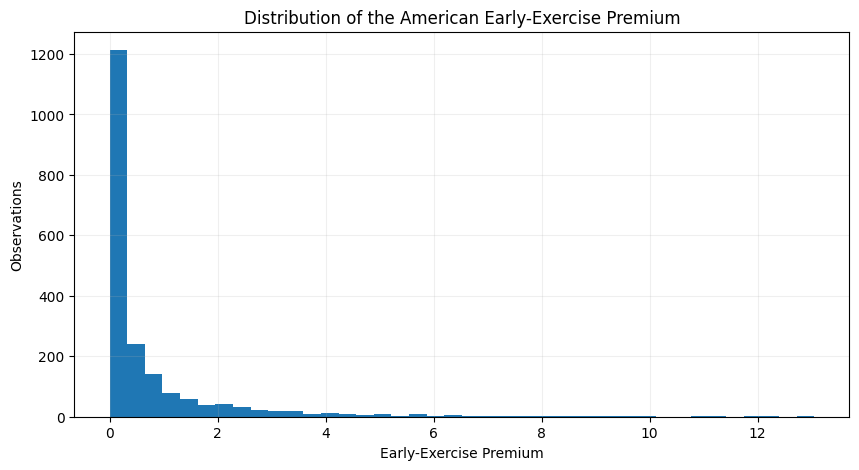

In [15]:
plt.figure(figsize=(10, 5))
plt.hist(pilot["early_exercise_premium"], bins=40)
plt.xlabel("Early-Exercise Premium")
plt.ylabel("Observations")
plt.title("Distribution of the American Early-Exercise Premium")
plt.grid(alpha=0.20)
plt.show()

A heavy concentration near zero would create an easy but misleading learning problem: a model could achieve a low global error by predicting a negligible premium for most observations. The later evaluation must therefore report errors by moneyness, maturity, volatility, and exercise region rather than relying on aggregate RMSE alone.

# 6. Exercise decision and boundary representation

The root exercise label is defined by comparing intrinsic and continuation value. The signed exercise gap is

$$
G = I - C.
$$

Positive values indicate the immediate-exercise region, while negative values indicate continuation. Observations with a small absolute normalized gap are especially valuable because they lie close to the optimal-stopping boundary.

In [16]:
pilot = pilot.copy()
pilot["exercise_gap"] = pilot["intrinsic_value"] - pilot["continuation_value"]
pilot["normalized_exercise_gap"] = pilot["exercise_gap"] / pilot["strike"]
pilot["absolute_normalized_exercise_gap"] = pilot["normalized_exercise_gap"].abs()

exercise_summary = (
    pilot.groupby("exercise_now", as_index=False)
    .agg(
        observations=("sample_id", "count"),
        mean_moneyness=("moneyness", "mean"),
        mean_maturity=("time_to_maturity", "mean"),
        mean_volatility=("volatility", "mean"),
        mean_rate=("risk_free_rate", "mean"),
        mean_dividend=("dividend_yield", "mean"),
        mean_premium=("early_exercise_premium", "mean"),
    )
)
exercise_summary["share"] = exercise_summary["observations"] / len(pilot)
exercise_summary

,exercise_now,observations,mean_moneyness,mean_maturity,mean_volatility,mean_rate,mean_dividend,mean_premium,share
0,False,1796,1.034482,1.028134,0.449391,0.048408,0.040921,0.463279,0.898
1,True,204,0.696438,0.846216,0.210283,0.064020,0.031897,3.056853,0.102


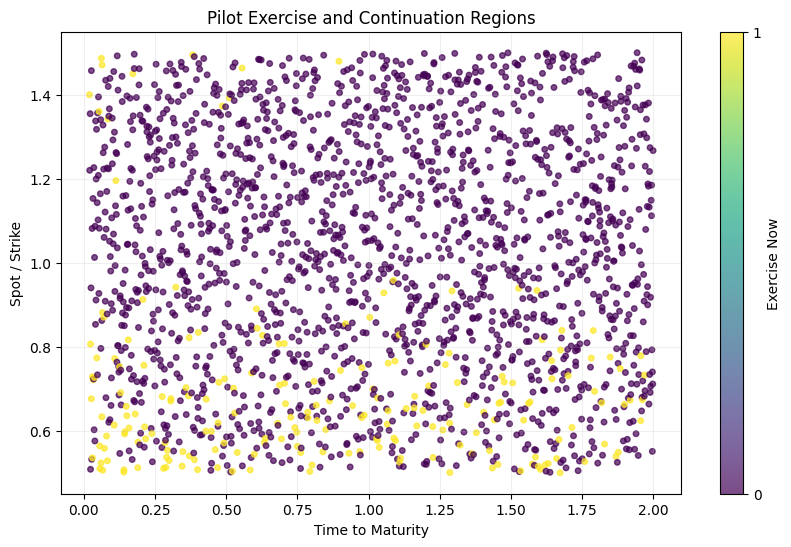

In [17]:
fig_data = pilot.sort_values(["time_to_maturity", "moneyness"])

plt.figure(figsize=(10, 6))
scatter = plt.scatter(
    fig_data["time_to_maturity"],
    fig_data["moneyness"],
    c=fig_data["exercise_now"].astype(int),
    s=16,
    alpha=0.70,
)
plt.colorbar(scatter, ticks=[0, 1], label="Exercise Now")
plt.xlabel("Time to Maturity")
plt.ylabel("Spot / Strike")
plt.title("Pilot Exercise and Continuation Regions")
plt.grid(alpha=0.20)
plt.show()

In [18]:
BOUNDARY_GAP_THRESHOLD = 0.01
boundary_candidates = pilot.loc[
    pilot["absolute_normalized_exercise_gap"] <= BOUNDARY_GAP_THRESHOLD
].copy()

pd.Series(
    {
        "Boundary threshold": BOUNDARY_GAP_THRESHOLD,
        "Boundary candidates": len(boundary_candidates),
        "Boundary candidate share": len(boundary_candidates) / len(pilot),
        "Exercise share among boundary candidates": (
            boundary_candidates["exercise_now"].mean()
            if len(boundary_candidates)
            else np.nan
        ),
    },
    name="Boundary coverage",
).to_frame()

,Boundary coverage
Boundary threshold,0.010000
Boundary candidates,583.000000
Boundary candidate share,0.291500
Exercise share among boundary candidates,0.349914


The production dataset should include a dedicated boundary-focused component if the pilot contains too few observations close to the transition. This is not class-label manipulation after observing model performance. It is a pre-model sampling decision justified by the structure of the optimal-stopping problem.

# 7. Deterministic train, validation, and in-domain test splits

The core dataset uses a fixed 70% / 15% / 15% split. Stratification is applied to the exercise decision where practical. The split assignments are saved separately so every subsequent model is evaluated on exactly the same observations.

The out-of-domain datasets are not part of this split. They will be generated or selected separately and will never be used to fit scalers, tune hyperparameters, or stop training.

In [19]:
split_config = SplitConfig(
    train_fraction=0.70,
    validation_fraction=0.15,
    test_fraction=0.15,
    seed=RANDOM_SEED,
    stratify_column="exercise_now",
)

pilot_splits = create_train_validation_test_split(
    pilot,
    config=split_config,
)

split_summary = pd.DataFrame(
    {
        "split": list(pilot_splits),
        "observations": [len(frame) for frame in pilot_splits.values()],
        "exercise_rate": [
            frame["exercise_now"].mean() for frame in pilot_splits.values()
        ],
        "mean_normalized_premium": [
            frame["normalized_early_exercise_premium"].mean()
            for frame in pilot_splits.values()
        ],
    }
)
split_summary["share"] = split_summary["observations"] / len(pilot)
split_summary

,split,observations,exercise_rate,mean_normalized_premium,share
0,train,1400,0.102143,0.007126,0.7000
1,validation,301,0.102990,0.007039,0.1505
2,test,299,0.100334,0.008233,0.1495


In [20]:
validate_split_integrity(pilot_splits, config=split_config)

,check,observed,expected,passed
0,Required split names are present,"[test, train, validation]","[test, train, validation]",True
1,ID column exists in every split,True,True,True
2,Split identifiers are disjoint,0,0,True
3,Stored split labels match their containers,True,True,True
4,All split rows are represented by unique IDs,2000,2000,True


In [21]:
pilot_split_manifest = build_split_manifest(
    pilot_splits,
    config=split_config,
    dataset_name="american_put_pilot",
)

save_split_assignments(
    pilot_splits,
    PILOT_SPLIT_PATH,
    config=split_config,
)
save_split_manifest(
    pilot_split_manifest,
    PILOT_SPLIT_MANIFEST_PATH,
)

print(f"Saved split assignments: {PILOT_SPLIT_PATH}")
print(f"Saved split manifest:    {PILOT_SPLIT_MANIFEST_PATH}")

Saved split assignments: D:\Users\kamen.dimitrov\Desktop\SOFTUNI\AI_and_ML_upskill_program\Deep_Learning\deep_learning_american_option_pricing\data\manifests\pilot_split_assignments.csv
Saved split manifest:    D:\Users\kamen.dimitrov\Desktop\SOFTUNI\AI_and_ML_upskill_program\Deep_Learning\deep_learning_american_option_pricing\data\manifests\pilot_split_manifest.json


# 8. Predefined out-of-domain regimes

Out-of-domain performance is evaluated on parameter regions outside the core training support. These regimes are defined before neural-network results are available.

In [22]:
ood_design = pd.DataFrame(
    [
        {
            "name": spec.name,
            "description": spec.description,
            "ranges": dict(spec.ranges),
        }
        for spec in DEFAULT_OOD_SPECS
    ]
)
ood_design

,name,description,ranges
0,high_volatility,Volatility above the core training maximum.,"{'volatility': (0.8, 1.2)}"
1,long_maturity,Maturities beyond the two-year core training h...,"{'time_to_maturity': (2.0, 4.0)}"
2,deep_in_the_money,Spot-to-strike ratios below the core domain.,"{'moneyness': (0.25, 0.5)}"
3,deep_out_of_the_money,Spot-to-strike ratios above the core domain.,"{'moneyness': (1.5, 2.0)}"
4,high_interest_rate,Interest rates above the core training maximum.,"{'risk_free_rate': (0.1, 0.2)}"
5,high_dividend_yield,Dividend yields above the core training maximum.,"{'dividend_yield': (0.08, 0.15)}"


The OOD sets are intentionally separate rather than a random tail of the core sample. This allows the final paper to distinguish interpolation accuracy from genuine domain extension. Strong in-domain performance will not be described as generalization unless the OOD results support that claim.

# 9. Production dataset design

The initial production design contains three components:

1. **Core dataset** — broad Latin hypercube coverage of the declared training domain;
2. **Boundary dataset** — observations concentrated where intrinsic and continuation values are close;
3. **OOD datasets** — separate stress regimes outside the core support.

The sample sizes below are planning values. The final tree resolution and production size must remain consistent with Notebook 02 runtime evidence.

In [23]:
production_design = {
    "manifest_version": 1,
    "status": "approved_design_before_production_generation",
    "random_seed": RANDOM_SEED,
    "core_dataset": {
        "planned_observations": 100_000,
        "sampling": "randomized_latin_hypercube",
        "strike": 100.0,
        "parameter_ranges": {
            "moneyness": [0.50, 1.50],
            "time_to_maturity": [7.0 / 365.0, 2.0],
            "volatility": [0.05, 0.80],
            "risk_free_rate": [0.00, 0.10],
            "dividend_yield": [0.00, 0.08],
        },
        "tree_steps": "Use the production value selected in Notebook 02",
    },
    "boundary_dataset": {
        "planned_observations": 30_000,
        "normalized_gap_threshold": BOUNDARY_GAP_THRESHOLD,
        "selection_metric": "abs(intrinsic_value-continuation_value)/strike",
    },
    "split": {
        "train": split_config.train_fraction,
        "validation": split_config.validation_fraction,
        "test": split_config.test_fraction,
        "seed": split_config.seed,
        "stratify_column": split_config.stratify_column,
    },
    "ood_sets": [
        {
            "name": spec.name,
            "description": spec.description,
            "ranges": {
                column: list(bounds) for column, bounds in spec.ranges.items()
            },
        }
        for spec in DEFAULT_OOD_SPECS
    ],
    "pilot_audit": {
        "pilot_source": pilot_source,
        "pilot_observations": len(pilot),
        "quality_checks_passed": quality_report.passed,
        "floor_repair_rate": float(
            quality_report.floor_summary.loc[0, "repair_rate"]
        ),
        "exercise_rate": float(pilot["exercise_now"].mean()),
        "boundary_candidate_share": float(
            len(boundary_candidates) / len(pilot)
        ),
        "black_scholes_proxy_mae": float(
            black_scholes_proxy_metrics["MAE"]
        ),
    },
}

DATASET_DESIGN_PATH.write_text(
    json.dumps(production_design, indent=2),
    encoding="utf-8",
)
print(f"Saved dataset design: {DATASET_DESIGN_PATH}")

Saved dataset design: D:\Users\kamen.dimitrov\Desktop\SOFTUNI\AI_and_ML_upskill_program\Deep_Learning\deep_learning_american_option_pricing\data\manifests\dataset_design.json


# 10. Approval gate before neural-network development

The data stage is considered complete only when:

- all mandatory dataset checks pass;
- tree-step selection is supported by Notebook 02 convergence and runtime evidence;
- pricing-floor repairs are quantified and acceptable;
- exercise and boundary observations are sufficiently represented;
- train, validation, and test assignments are frozen;
- OOD regimes are documented and excluded from training;
- the Black–Scholes proxy baseline is saved for later comparison.

The next notebook should not begin with model architecture selection. It should first load the frozen split assignments and verify that preprocessing is fitted on the training subset only.

# 11. References used in this notebook

Cox, J. C., Ross, S. A., & Rubinstein, M. (1979). Option pricing: A simplified approach. *Journal of Financial Economics, 7*(3), 229–263.

Ding, L., Lu, E., & Cheung, K. (2025). *Deep learning option pricing with market implied volatility surfaces*. arXiv:2509.05911.

Ke, A., & Yang, A. (2019). *Option pricing with deep learning*. CS230, Stanford University.

Pu, V. R. H. (2021). *Pricing options using deep neural networks from a practical perspective* [Master’s thesis, Imperial College London].